In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [2]:
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
brain-tumor-classification-mri.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import zipfile
import os

zip_ref = zipfile.ZipFile('/content/brain-tumor-classification-mri.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import keras
import tensorflow

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,Activation,GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam, SGD

In [6]:
import matplotlib.pyplot as plt

In [7]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/Training',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 2870 files belonging to 4 classes.


In [8]:
test_ds=keras.utils.image_dataset_from_directory(
    directory='/content/Testing',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 394 files belonging to 4 classes.


In [9]:
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

train_ds=train_ds.map(process)
test_ds=test_ds.map(process)

In [10]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [52]:
from tensorflow.keras.optimizers import Adam

learning_rate = 3e-4
model = Sequential()

# Block 1
model.add(Conv2D(64, kernel_size=(3,3), padding='same', use_bias=False,
                 input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=2))


# Block 2
model.add(Conv2D(128, kernel_size=(3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(128, kernel_size=(3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=2))


# Block 3
model.add(Conv2D(256, kernel_size=(3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(256, kernel_size=(3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=2))


# Block 4
model.add(Conv2D(512, kernel_size=(3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(512, kernel_size=(3,3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2), strides=2))


model.add(GlobalAveragePooling2D())

model.add(Dense(
    256,
    kernel_regularizer=tf.keras.regularizers.l2(0.001),
    kernel_initializer='he_uniform',
    use_bias=False
))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

model.add(Dense(
    128,
    kernel_regularizer=tf.keras.regularizers.l2(0.001),
    kernel_initializer='he_uniform',
    use_bias=False
))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

model.add(Dense(4, activation='softmax'))

In [55]:
optimizer=Adam(learning_rate=3e-4)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    min_delta=0,
    verbose=0,
    mode='auto',
    patience=5,
    restore_best_weights=False,
    baseline=None
)

In [57]:
train_size = 0

for images, labels in train_ds:
    train_size += images.shape[0]

print(train_size)

2870


In [59]:
history=model.fit(train_ds,epochs=25,validation_data=test_ds, batch_size=32)

Epoch 1/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 494ms/step - accuracy: 0.7697 - loss: 1.3216 - val_accuracy: 0.2944 - val_loss: 3.5269
Epoch 2/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 499ms/step - accuracy: 0.8000 - loss: 1.2290 - val_accuracy: 0.3173 - val_loss: 2.6610
Epoch 3/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 506ms/step - accuracy: 0.8167 - loss: 1.1705 - val_accuracy: 0.3376 - val_loss: 3.6986
Epoch 4/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 507ms/step - accuracy: 0.8181 - loss: 1.1406 - val_accuracy: 0.3959 - val_loss: 3.7746
Epoch 5/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 509ms/step - accuracy: 0.8390 - loss: 1.0681 - val_accuracy: 0.3934 - val_loss: 2.7425
Epoch 6/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 514ms/step - accuracy: 0.8575 - loss: 1.0084 - val_accuracy: 0.4340 - val_loss: 2.6537
Epoch 7/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 513ms/step - accuracy: 0.8585 - loss: 0.9803 - val_accuracy: 0.4594 - val_loss: 2.6968
Epoch 8/25
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 511ms/step - accuracy: 0.8700 - loss: 0.9380 - val_accu

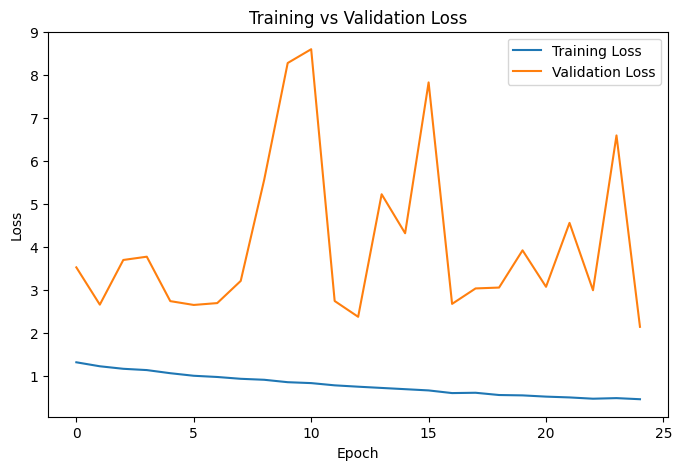

In [60]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

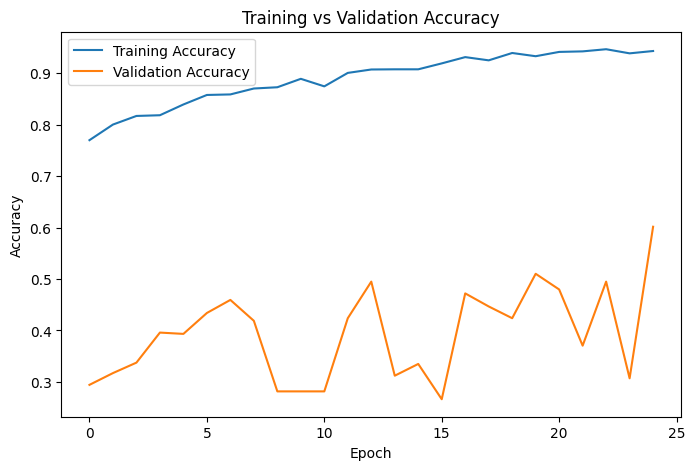

In [61]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()